# Data cleaning — seven-zone hourly panel

Builds an hourly panel of day-ahead prices and forecasts for seven bidding zones:
`DK1`, `DK2`, `NL`, `DE_LU`, `NO2`, `SE3`, `SE4`.

Three steps: read those zones from the raw ENTSO-E dump, collapse every series to
the clock hour, then measure what is missing.

Everything works in **UTC**, where every day has 24 hours and DST does not exist,
so a hole is a hole in what the platform published. Local market time is a later
concern.

## 1. Load

Reads the day-ahead price, load forecast and wind & solar generation forecast for
the seven zones over the local delivery window **2019-01-01 00:00 through
2025-09-30 23:00 Europe/Copenhagen**. These bounds are converted to UTC before
they become parquet predicates: 2018-12-31 23:00 through 2025-09-30 21:00 UTC.
The zone list, reservoir exclusion and both time bounds are pushed into the scan.

The local window ends there because the next hour is where the day-ahead market
time unit becomes 15 minutes. It is the first hour whose four quarters carry
different prices in DK1, DK2, NL, NO2, SE3 and SE4, so every price hour read is
one the auction cleared as a single hourly product. The bound covers the final
hour in full: its `PT15M` slots are read too, so it collapses from four quarters
rather than from one.

DE-LU is handled explicitly: its parallel `PT15M` prices are a distinct
quarter-hourly auction product, not a finer-resolution representation of the
`PT60M` hourly auction. Only DE-LU `PT60M` prices enter this pipeline.

Water reservoir & hydro storage [16.1.D] is excluded: it is published weekly
(`P7D`) as a stock level, not per market time unit as a flow.

Assertions guard the read: every requested zone is defined and returned rows,
timestamps stay inside the converted local window, DE-LU prices are exclusively
`PT60M`, and no retained price hour constructed from quarters contains differing
quarter-hour prices.

In [47]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import pyarrow.parquet as pq

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.width", 220)
pd.set_option("display.max_rows", 250)
pd.set_option("display.max_columns", 60)

# Resolve the raw dump relative to the notebook, wherever it is opened from.
CANDIDATES = [
    Path("datasets/nordic_baltic_raw.parquet"),
    Path("../datasets/nordic_baltic_raw.parquet"),
    Path("../../datasets/nordic_baltic_raw.parquet"),
]
RAW = next((p for p in CANDIDATES if p.exists()), None)
if RAW is None:
    raise FileNotFoundError(
        "nordic_baltic_raw.parquet not found. Set RAW manually to its path."
    )

# Zone timezones come from the package that produced the file, so the two cannot
# drift apart.
sys.path.insert(0, str(RAW.parent.parent))
from entsoe_tp.areas import AREAS, lookup  # noqa: E402

# --- what gets read -----------------------------------------------------------
# The zones covered, the variable left out, and the local delivery window. The
# local bounds are converted to UTC before becoming parquet scan predicates.
ZONES = ["DK1", "DK2", "NL", "DE_LU", "NO2", "SE3", "SE4"]
EXCLUDE_VARIABLES = ["reservoir"]
MARKET_TIMEZONE = "Europe/Copenhagen"
LOCAL_START = pd.Timestamp("2019-01-01 00:00")
LOCAL_END = pd.Timestamp("2025-09-30 23:00")
START_UTC = LOCAL_START.tz_localize(MARKET_TIMEZONE).tz_convert("UTC")
END_UTC = LOCAL_END.tz_localize(MARKET_TIMEZONE).tz_convert("UTC")

unknown = sorted(set(ZONES) - set(AREAS))
assert not unknown, f"not defined in entsoe_tp.areas: {unknown}"

# psrType codes carried by the wind & solar forecast document (A69), spelled out at
# load time so every table below reads in words rather than codes. Unlisted codes
# pass through as themselves, so a new production type stays visible.
PSR_NAMES = {"B16": "solar", "B18": "wind_offshore", "B19": "wind_onshore"}

KEY = ["zone", "variable", "psr_type", "resolution", "timestamp_utc"]
CAT = ["zone", "eic", "variable", "document_type", "process_type", "resolution",
       "psr_type", "business_type", "curve_type", "contract_type", "unit", "currency"]


def load_raw(path=RAW, zones=ZONES, exclude=EXCLUDE_VARIABLES,
             start=START_UTC, end=END_UTC) -> pd.DataFrame:
    """Read the rows this pipeline uses, and normalise the dictionary-encoded columns.

    ``zones``, ``exclude``, ``start`` and ``end`` are pushed into the parquet scan as
    row filters, so only the matching rows are materialised.

    Nulls become empty strings on purpose: pandas treats NaN keys as *equal* in
    duplicated()/drop_duplicates(), which silently collapses every price row
    (psr_type is null for prices) into a single group. Empty strings behave correctly.
    """
    filters = [("zone", "in", list(zones))]
    if exclude:
        filters.append(("variable", "not in", list(exclude)))
    if start is not None:
        filters.append(("timestamp_utc", ">=", start))
    if end is not None:
        # The bound covers the whole hour `end` labels, sub-hourly slots included,
        # so that hour collapses from a full set of quarters rather than its first.
        filters.append(("timestamp_utc", "<", end + pd.Timedelta(hours=1)))

    df = pq.read_table(path, filters=filters).to_pandas()
    for c in CAT:
        if c in df.columns:
            df[c] = df[c].astype("object").fillna("").astype(str)

    # DE-LU publishes two parallel day-ahead price products under the same EIC.
    # PT15M is a distinct quarter-hourly auction, not a finer-resolution view of
    # the PT60M hourly auction used here, so never allow generic precedence to
    # switch products when one series ends.
    de_lu_quarter_price = (
        (df["zone"] == "DE_LU")
        & (df["variable"] == "price")
        & (df["resolution"] == "PT15M")
    )
    df = df.loc[~de_lu_quarter_price].copy()

    df["psr_type"] = df["psr_type"].replace(PSR_NAMES)
    df["series"] = (
        df["zone"] + " | " + df["variable"]
        + np.where(df["psr_type"] != "", " [" + df["psr_type"] + "]", "")
    )
    # Zone order follows ZONES rather than the alphabet, so every table below reads
    # in the order the thesis lists them.
    df["zone"] = pd.Categorical(df["zone"], categories=list(zones), ordered=True)
    return df


raw = load_raw()

# A zone defined in areas.py but never captured by the dump would otherwise pass
# silently as an empty slice.
absent = [z for z in ZONES if not (raw.zone == z).any()]
assert not absent, f"no rows in the dump for {absent} -- has raw_dump run for them?"
assert not set(raw.variable) & set(EXCLUDE_VARIABLES), "an excluded variable was read"
assert raw.timestamp_utc.min() >= START_UTC, "a stamp before START_UTC"
assert raw.timestamp_utc.max() < END_UTC + pd.Timedelta(hours=1), "a stamp past END_UTC"
assert raw.loc[(raw.zone == "DE_LU") & (raw.variable == "price"), "resolution"].eq("PT60M").all(), \
    "a DE-LU quarter-hourly auction price survived the explicit product filter"

# The local end exists to keep quarter-varying prices out of the panel, so that is
# asserted rather than trusted. Every retained price hour constructed from PT15M
# must carry one repeated auction price across its quarters.
_p = raw.loc[raw.variable == "price",
             ["series", "resolution", "timestamp_utc", "value"]].copy()
_p["hour"] = _p.timestamp_utc.dt.floor("h")
_p = _p.groupby(["series", "hour"], observed=True).agg(
    has_hourly=("resolution", lambda r: (r == "PT60M").any()),
    distinct=("value", "nunique"))
assert not ((~_p.has_hourly) & (_p.distinct > 1)).any(), \
    "a price hour with differing quarters and no hourly value was read"

print(f"file        : {RAW.resolve()}")
print(f"zones       : {', '.join(ZONES)}")
print(f"not read    : {', '.join(EXCLUDE_VARIABLES) if EXCLUDE_VARIABLES else '(nothing)'}")
print(f"local window: {LOCAL_START} -> {LOCAL_END} ({MARKET_TIMEZONE})")
print(f"UTC window  : {START_UTC} -> {END_UTC}")
print(f"{len(raw):,} rows x {raw.shape[1]} columns | {raw.series.nunique()} series")
print(f"span        : {raw.timestamp_utc.min()} -> {raw.timestamp_utc.max()} (UTC)")
print(f"variables   : {', '.join(sorted(raw.variable.unique()))}")

display(raw.groupby(["zone", "variable", "psr_type"], observed=True)
           .agg(rows=("value", "size"),
                resolutions=("resolution", lambda s: ",".join(sorted(s.unique()))),
                first=("timestamp_utc", "min"),
                last=("timestamp_utc", "max")))

file        : C:\Users\Frede\OneDrive\Skrivebord\Masters Thesis v2\Code\EPF_Masters\datasets\nordic_baltic_raw.parquet
zones       : DK1, DK2, NL, DE_LU, NO2, SE3, SE4
not read    : reservoir
local window: 2019-01-01 00:00:00 -> 2025-09-30 23:00:00 (Europe/Copenhagen)
UTC window  : 2018-12-31 23:00:00+00:00 -> 2025-09-30 21:00:00+00:00
3,426,038 rows x 15 columns | 33 series
span        : 2018-12-31 23:00:00+00:00 -> 2025-09-30 21:45:00+00:00 (UTC)
variables   : generation_forecast, load_forecast, price


rows  resolutions                     first                      last
zone  variable            psr_type                                                                              
DK1   generation_forecast solar           71297  PT15M,PT60M 2018-12-31 23:00:00+00:00 2025-09-30 21:45:00+00:00
                          wind_offshore   71321  PT15M,PT60M 2018-12-31 23:00:00+00:00 2025-09-30 21:45:00+00:00
                          wind_onshore    71246  PT15M,PT60M 2018-12-31 23:00:00+00:00 2025-09-30 21:45:00+00:00
      load_forecast                       59159        PT60M 2018-12-31 23:00:00+00:00 2025-09-30 21:00:00+00:00
      price                               61103        PT60M 2018-12-31 23:00:00+00:00 2025-09-30 21:00:00+00:00
DK2   generation_forecast solar           71337  PT15M,PT60M 2018-12-31 23:00:00+00:00 2025-09-30 21:45:00+00:00
                          wind_offshore   71321  PT15M,PT60M 2018-12-31 23:00:00+00:00 2025-09-30 21:45:00+00:00
                          wind_onshore    71225  PT15M,PT60M 2018-12-31 23:00:00+00:00 2025-09-30 21:45:00+00:00
      load_forecast                       59159        PT60M 2018-12-31 23:00:00+00:00 2025-09-30 21:00:00+00:00
      price                               61103        PT60M 2018-12-31 23:00:00+00:00 2025-09-30 21:00:00+00:00
NL    generation_forecast solar          236540        PT15M 2018-12-31 23:00:00+00:00 2025-09-30 21:45:00+00:00
                          wind_offshore  236540        PT15M 2018-12-31 23:00:00+00:00 2025-09-30 21:45:00+00:00
                          wind_onshore   236540        PT15M 2018-12-31 23:00:00+00:00 2025-09-30 21:45:00+00:00
      load_forecast                      236636        PT15M 2018-12-31 23:00:00+00:00 2025-09-30 21:45:00+00:00
      price                               61103        PT60M 2018-12-31 23:00:00+00:00 2025-09-30 21:00:00+00:00
DE_LU generation_forecast solar          236628        PT15M 2018-12-31 23:00:00+00:00 2025-09-30 21:45:00+00:00
                          wind_offshore  236636        PT15M 2018-12-31 23:00:00+00:00 2025-09-30 21:45:00+00:00
                          wind_onshore   236628        PT15M 2018-12-31 23:00:00+00:00 2025-09-30 21:45:00+00:00
      load_forecast                      236436        PT15M 2018-12-31 23:00:00+00:00 2025-09-30 21:45:00+00:00
      price                               61103        PT60M 2018-12-31 23:00:00+00:00 2025-09-30 21:00:00+00:00
NO2   generation_forecast solar           73359  PT15M,PT60M 2018-12-31 23:00:00+00:00 2025-09-30 21:45:00+00:00
                          wind_offshore   19822  PT15M,PT60M 2018-12-31 23:00:00+00:00 2025-09-30 21:45:00+00:00
                          wind_onshore    73359  PT15M,PT60M 2018-12-31 23:00:00+00:00 2025-09-30 21:45:00+00:00
      load_forecast                       73337  PT15M,PT60M 2018-12-31 23:00:00+00:00 2025-09-30 21:45:00+00:00
      price                               77444  PT15M,PT60M 2018-12-31 23:00:00+00:00 2025-09-30 21:45:00+00:00
SE3   generation_forecast solar           33503        PT60M 2021-12-01 23:00:00+00:00 2025-09-30 21:00:00+00:00
                          wind_onshore    59063        PT60M 2018-12-31 23:00:00+00:00 2025-09-30 21:00:00+00:00
      load_forecast                       59159        PT60M 2018-12-31 23:00:00+00:00 2025-09-30 21:00:00+00:00
      price                               61103        PT60M 2018-12-31 23:00:00+00:00 2025-09-30 21:00:00+00:00
SE4   generation_forecast solar           33503        PT60M 2021-12-01 23:00:00+00:00 2025-09-30 21:00:00+00:00
                          wind_onshore    59063        PT60M 2018-12-31 23:00:00+00:00 2025-09-30 21:00:00+00:00
      load_forecast                       59159        PT60M 2018-12-31 23:00:00+00:00 2025-09-30 21:00:00+00:00
      price                               61103        PT60M 2018-12-31 23:00:00+00:00 2025-09-30 21:00:00+00:00

## 2. Duplicate rows

Two rows sharing the full key — zone, variable, production type, resolution and
timestamp — are two copies of one observation. Downloads are chunked by month with
inclusive endpoints, so consecutive chunks overlap at the join.

Counted first, dropped second. The analysis reports how many copies each key
carries, whether those copies agree on their value, and where the duplicated
stamps sit in the calendar month. A key whose copies disagree is one where
`keep="first"` selects between different numbers.

In [48]:
dup_any = raw.duplicated(KEY, keep=False)
redundant = int(raw.duplicated(KEY, keep="first").sum())

print(f"rows on a duplicated key: {int(dup_any.sum()):,} of {len(raw):,}")
print(f"redundant copies        : {redundant:,}")
print(f"keys carrying them      : {int(dup_any.sum()) - redundant:,}")

if not redundant:
    print("\nno duplicate keys")
else:
    # `series` encodes zone, variable and psr_type, so this grouping is the full key.
    per_key = (raw.loc[dup_any]
                  .groupby(["series", "resolution", "timestamp_utc"], observed=True)["value"]
                  .agg(copies="size", distinct="nunique", lo="min", hi="max"))
    per_key["spread"] = per_key["hi"] - per_key["lo"]
    pk = per_key.reset_index()

    print("\ncopies per duplicated key:")
    display(pk.copies.value_counts().sort_index()
              .rename_axis("copies").to_frame("keys"))

    # A key whose copies disagree makes keep="first" a choice rather than a formality.
    conflicting = pk[pk.distinct > 1]
    print(f"keys whose copies disagree on value: {len(conflicting):,} of {len(pk):,}")
    if len(conflicting):
        print("largest disagreements:")
        display(conflicting.nlargest(20, "spread").reset_index(drop=True))

    print("\nper series:")
    display(pk.groupby("series", observed=True)
              .agg(duplicated_stamps=("timestamp_utc", "size"),
                   redundant_copies=("copies", lambda c: int((c - 1).sum())),
                   disagreeing=("distinct", lambda x: int((x > 1).sum())),
                   max_spread=("spread", "max"),
                   first=("timestamp_utc", "min"),
                   last=("timestamp_utc", "max")))

    print("\nwhere the duplicated stamps sit in the month:")
    display(pk.timestamp_utc.dt.day.value_counts().sort_index()
              .rename_axis("day_of_month").to_frame("duplicated_stamps"))

rows on a duplicated key: 28,224 of 3,426,038
redundant copies        : 14,112
keys carrying them      : 14,112

copies per duplicated key:


,keys
copies,
2,14112


keys whose copies disagree on value: 0 of 14,112

per series:


,duplicated_stamps,redundant_copies,disagreeing,max_spread,first,last
series,,,,,,
DE_LU | price,1944,1944,0,0.0,2018-12-31 23:00:00+00:00,2025-09-01 21:00:00+00:00
DK1 | price,1944,1944,0,0.0,2018-12-31 23:00:00+00:00,2025-09-01 21:00:00+00:00
DK2 | price,1944,1944,0,0.0,2018-12-31 23:00:00+00:00,2025-09-01 21:00:00+00:00
NL | price,1944,1944,0,0.0,2018-12-31 23:00:00+00:00,2025-09-01 21:00:00+00:00
NO2 | price,2448,2448,0,0.0,2018-12-31 23:00:00+00:00,2025-09-01 21:45:00+00:00
SE3 | price,1944,1944,0,0.0,2018-12-31 23:00:00+00:00,2025-09-01 21:00:00+00:00
SE4 | price,1944,1944,0,0.0,2018-12-31 23:00:00+00:00,2025-09-01 21:00:00+00:00



where the duplicated stamps sit in the month:


,duplicated_stamps
day_of_month,
1,13170
28,38
29,14
30,334
31,556


In [49]:
# Having been counted and characterised above, the redundant copies are dropped.
n = len(raw)
deduped = raw.drop_duplicates(KEY, keep="first").copy()

assert not deduped.duplicated(KEY).any(), "a duplicate key survived"
print(f"drop redundant copies: {n:,} -> {len(deduped):,}  (-{n - len(deduped):,})")

drop redundant copies: 3,426,038 -> 3,411,926  (-14,112)


## 3. Do the PT15M quarters vary within the hour?

A `PT15M` stamp does not by itself mean quarter-hourly data. A zone that switched
its publication format before the auction cleared sub-hourly repeats one hourly
value across all four quarters, and a zone publishing a genuinely quarter-hourly
product does not.

The distinction decides what the collapse in section 4 does. Where the four values
of an hour are identical, the mean returns that value exactly. Where they differ,
the mean is a summary of four separate values.

Per series below: how many `PT15M` hours vary within the hour, the first hour that
varies, the largest within-hour spread, and the monthly share of varying hours.
Hours whose four values are all zero are counted separately as inactive.

In [50]:
q = deduped.loc[deduped.resolution == "PT15M",
                ["series", "timestamp_utc", "value"]].copy()

if not len(q):
    print("no PT15M rows")
else:
    q["hour_utc"] = q.timestamp_utc.dt.floor("h")

    per_hour = (q.groupby(["series", "hour_utc"], observed=True)["value"]
                  .agg(slots="size", distinct="nunique", lo="min", hi="max"))
    per_hour["spread"] = per_hour["hi"] - per_hour["lo"]
    per_hour["varies"] = per_hour["distinct"] > 1
    # An all-zero hour cannot vary, so it is counted apart: solar at night would
    # otherwise drag the varying share down.
    per_hour["active"] = per_hour[["lo", "hi"]].abs().max(axis=1) > 1e-9
    ph = per_hour.reset_index()

    print(f"{len(ph):,} PT15M hours across {ph.series.nunique()} series | "
          f"{int(ph.varies.sum()):,} vary within the hour ({100 * ph.varies.mean():.2f}%)")

    active = ph[ph.active]
    first_varying = (ph[ph.varies].groupby("series", observed=True)["hour_utc"]
                       .min().rename("first_varying_hour"))
    pct_active = (100 * active.groupby("series", observed=True)["varies"].mean()
                  ).round(2).rename("pct_varying_active")

    summary = (ph.groupby("series", observed=True)
                 .agg(pt15_hours=("varies", "size"),
                      varying=("varies", "sum"),
                      inactive_hours=("active", lambda a: int((~a).sum())),
                      max_spread=("spread", "max"),
                      first_pt15=("hour_utc", "min"),
                      last_pt15=("hour_utc", "max"))
                 .join(first_varying)
                 .join(pct_active))
    summary["pct_varying"] = (100 * summary.varying / summary.pt15_hours).round(2)
    display(summary)

    print("\nmonthly share of active PT15M hours that vary within the hour:")
    display(active.assign(month=active.hour_utc.dt.tz_convert(None).dt.to_period("M"))
                  .pivot_table(index="month", columns="series", values="varies",
                               aggfunc="mean")
                  .round(3))

518,011 PT15M hours across 19 series | 454,810 vary within the hour (87.80%)


,pt15_hours,varying,inactive_hours,max_spread,first_pt15,last_pt15,first_varying_hour,pct_varying_active,pct_varying
series,,,,,,,,,
DE_LU | generation_forecast [solar],59157,34220,24937,9900.54,2018-12-31 23:00:00+00:00,2025-09-30 21:00:00+00:00,2019-01-01 07:00:00+00:00,100.00,57.85
DE_LU | generation_forecast [wind_offshore],59159,59159,0,1214.59,2018-12-31 23:00:00+00:00,2025-09-30 21:00:00+00:00,2018-12-31 23:00:00+00:00,100.00,100.00
DE_LU | generation_forecast [wind_onshore],59157,59157,0,4895.60,2018-12-31 23:00:00+00:00,2025-09-30 21:00:00+00:00,2018-12-31 23:00:00+00:00,100.00,100.00
DE_LU | load_forecast,59109,59109,0,9734.89,2018-12-31 23:00:00+00:00,2025-09-30 21:00:00+00:00,2018-12-31 23:00:00+00:00,100.00,100.00
DK1 | generation_forecast [solar],4174,3550,332,584.15,2025-04-08 00:00:00+00:00,2025-09-30 21:00:00+00:00,2025-04-10 01:00:00+00:00,92.40,85.05
DK1 | generation_forecast [wind_offshore],4126,4098,2,213.50,2025-04-08 00:00:00+00:00,2025-09-30 21:00:00+00:00,2025-04-09 22:00:00+00:00,99.37,99.32
DK1 | generation_forecast [wind_onshore],4132,4108,0,312.83,2025-04-08 00:00:00+00:00,2025-09-30 21:00:00+00:00,2025-04-09 00:00:00+00:00,99.42,99.42
DK2 | generation_forecast [solar],4172,3366,523,198.72,2025-04-08 00:00:00+00:00,2025-09-30 21:00:00+00:00,2025-04-10 03:00:00+00:00,92.24,80.68
DK2 | generation_forecast [wind_offshore],4126,4087,3,186.50,2025-04-08 00:00:00+00:00,2025-09-30 21:00:00+00:00,2025-04-09 22:00:00+00:00,99.13,99.05



monthly share of active PT15M hours that vary within the hour:


series,DE_LU | generation_forecast [solar],DE_LU | generation_forecast [wind_offshore],DE_LU | generation_forecast [wind_onshore],DE_LU | load_forecast,DK1 | generation_forecast [solar],DK1 | generation_forecast [wind_offshore],DK1 | generation_forecast [wind_onshore],DK2 | generation_forecast [solar],DK2 | generation_forecast [wind_offshore],DK2 | generation_forecast [wind_onshore],NL | generation_forecast [solar],NL | generation_forecast [wind_offshore],NL | generation_forecast [wind_onshore],NL | load_forecast,NO2 | generation_forecast [wind_offshore],NO2 | generation_forecast [wind_onshore],NO2 | load_forecast,NO2 | price
month,,,,,,,,,,,,,,,,,,
2018-12,NaN,1.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000,1.000,1.0,NaN,NaN,NaN,NaN
2019-01,1.0,1.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,0.997,0.974,0.999,1.0,NaN,NaN,NaN,NaN
2019-02,1.0,1.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,0.997,0.972,0.997,1.0,NaN,NaN,NaN,NaN
2019-03,1.0,1.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,1.000,0.960,1.000,1.0,NaN,NaN,NaN,NaN
2019-04,1.0,1.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,1.000,0.999,1.000,1.0,NaN,NaN,NaN,NaN
2019-05,1.0,1.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,1.000,0.991,0.997,1.0,NaN,NaN,NaN,NaN
2019-06,1.0,1.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,1.000,0.986,0.999,1.0,NaN,NaN,NaN,NaN
2019-07,1.0,1.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,1.000,0.988,0.997,1.0,NaN,NaN,NaN,NaN
2019-08,1.0,1.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,1.000,0.984,1.000,1.0,NaN,NaN,NaN,NaN


## 4. Collapse to the clock hour

Native resolutions differ across the seven zones. NL publishes its load and
generation forecasts at `PT15M` for its whole history and DE-LU from 2018; DK1,
DK2 and NO2 switch from `PT60M` to `PT15M` during 2025; SE3 and SE4 are hourly
throughout. This step puts them all on one hourly UTC grid.

Two things are decided here, and each is reported:

1. **Sub-hourly values are averaged within the clock hour.** For an MW quantity
   that is the hourly average. For retained prices, the four quarters are
   identical and the mean returns the published hourly price exactly. Hours
   arriving with fewer slots than their resolution implies are counted
   separately; the mean is then taken over part of an hour.

2. **An hour carrying both resolutions takes the `PT60M` value.** This generic
   rule reconciles overlapping publication formats for non-price series. DE-LU
   prices do not rely on it: the distinct `PT15M` auction product was removed by
   name during loading, and an assertion after collapse guarantees every retained
   DE-LU price hour has `source_resolution == "PT60M"`.

In [51]:
# Slots per clock hour, which is also the guard: anything coarser than an hour would
# be relabelled PT60M by the collapse below. The weekly reservoir series is never
# read (section 1), so this only guards a future change to EXCLUDE_VARIABLES.
SLOTS_PER_HOUR = {"PT60M": 1, "PT15M": 4}

stray = sorted(set(deduped.resolution.unique()) - set(SLOTS_PER_HOUR))
assert not stray, f"resolution(s) {stray} are coarser than an hour"

# 1. collapse to the clock hour, per resolution, so a PT60M value is never averaged
# together with the PT15M quarters of the same hour
d = deduped.copy()
d["hour_utc"] = d.timestamp_utc.dt.floor("h")
GROUP = [c for c in ["zone", "eic", "variable", "document_type", "process_type",
                     "psr_type", "business_type", "curve_type", "contract_type",
                     "unit", "currency", "series", "resolution", "hour_utc"]
         if c in d.columns]

folded = (d.groupby(GROUP, as_index=False, observed=True)
            .agg(value=("value", "mean"), slots=("value", "size")))
print(f"1. collapse to the hour: {len(d):,} -> {len(folded):,}  (-{len(d) - len(folded):,})")

folded["expected_slots"] = folded.resolution.map(SLOTS_PER_HOUR)
partial = folded[folded.slots < folded.expected_slots]
print(f"   partial hours       : {len(partial):,} "
      f"({100 * len(partial) / len(folded):.4f}% of collapsed hours)")

1. collapse to the hour: 3,411,926 -> 1,857,896  (-1,554,030)
   partial hours       : 1 (0.0001% of collapsed hours)


In [52]:
# 2. hours carrying both resolutions: how far do the two published versions differ?
overlap = folded.pivot_table(index=["series", "hour_utc"], columns="resolution",
                             values="value", aggfunc="first")
pair = [c for c in ("PT60M", "PT15M") if c in overlap.columns]

if len(pair) == 2:
    both = overlap.dropna(subset=pair).copy()
    both["abs_diff"] = (both["PT60M"] - both["PT15M"]).abs()
    print(f"hours published at both resolutions: {len(both):,}")
    if len(both):
        display(both.reset_index().groupby("series", observed=True)
                    .agg(hours=("abs_diff", "size"),
                         max_abs_diff=("abs_diff", "max"),
                         median_abs_diff=("abs_diff", "median"),
                         hours_differing=("abs_diff", lambda s: int((s > 1e-9).sum())),
                         first=("hour_utc", "min"), last=("hour_utc", "max")))
else:
    print("only one resolution present; nothing to reconcile")

hours published at both resolutions: 0


In [53]:
# PT60M wins where an hour carries both; the PT15M mean fills the rest.
PRECEDENCE = ["PT60M", "PT15M"]

folded["_rank"] = folded.resolution.map({r: i for i, r in enumerate(PRECEDENCE)})
hourly = (folded.sort_values(["series", "hour_utc", "_rank"])
                .drop_duplicates(["series", "hour_utc"], keep="first")
                .drop(columns="_rank")
                .rename(columns={"hour_utc": "timestamp_utc",
                                 "resolution": "source_resolution"})
                .reset_index(drop=True))

assert not hourly.duplicated(["series", "timestamp_utc"]).any(), \
    "a series still has two values for one hour"
assert hourly.timestamp_utc.dt.minute.eq(0).all(), "a stamp is not on the hour"
assert hourly.loc[(hourly.zone == "DE_LU") & (hourly.variable == "price"),
                  "source_resolution"].eq("PT60M").all(), \
    "a retained DE-LU price hour came from the quarter-hourly auction"

print(f"3. one row per series-hour: {len(folded):,} -> {len(hourly):,}  "
      f"(-{len(folded) - len(hourly):,})")
print(f"\n{len(hourly):,} rows | {hourly.series.nunique()} series | "
      f"{hourly.zone.nunique()} zones")
print(f"span: {hourly.timestamp_utc.min()} -> {hourly.timestamp_utc.max()} (UTC)")

display(hourly.groupby(["zone", "variable", "psr_type"], observed=True)
              .agg(hours=("value", "size"),
                   source=("source_resolution", lambda s: ",".join(sorted(s.unique()))),
                   first=("timestamp_utc", "min"),
                   last=("timestamp_utc", "max")))

3. one row per series-hour: 1,857,896 -> 1,857,896  (-0)

1,857,896 rows | 33 series | 7 zones
span: 2018-12-31 23:00:00+00:00 -> 2025-09-30 21:00:00+00:00 (UTC)


hours       source                     first                      last
zone  variable            psr_type                                                                             
DK1   generation_forecast solar          58775  PT15M,PT60M 2018-12-31 23:00:00+00:00 2025-09-30 21:00:00+00:00
                          wind_offshore  58943  PT15M,PT60M 2018-12-31 23:00:00+00:00 2025-09-30 21:00:00+00:00
                          wind_onshore   58853  PT15M,PT60M 2018-12-31 23:00:00+00:00 2025-09-30 21:00:00+00:00
      load_forecast                      59159        PT60M 2018-12-31 23:00:00+00:00 2025-09-30 21:00:00+00:00
      price                              59159        PT60M 2018-12-31 23:00:00+00:00 2025-09-30 21:00:00+00:00
DK2   generation_forecast solar          58821  PT15M,PT60M 2018-12-31 23:00:00+00:00 2025-09-30 21:00:00+00:00
                          wind_offshore  58943  PT15M,PT60M 2018-12-31 23:00:00+00:00 2025-09-30 21:00:00+00:00
                          wind_onshore   58847  PT15M,PT60M 2018-12-31 23:00:00+00:00 2025-09-30 21:00:00+00:00
      load_forecast                      59159        PT60M 2018-12-31 23:00:00+00:00 2025-09-30 21:00:00+00:00
      price                              59159        PT60M 2018-12-31 23:00:00+00:00 2025-09-30 21:00:00+00:00
NL    generation_forecast solar          59135        PT15M 2018-12-31 23:00:00+00:00 2025-09-30 21:00:00+00:00
                          wind_offshore  59135        PT15M 2018-12-31 23:00:00+00:00 2025-09-30 21:00:00+00:00
                          wind_onshore   59135        PT15M 2018-12-31 23:00:00+00:00 2025-09-30 21:00:00+00:00
      load_forecast                      59159        PT15M 2018-12-31 23:00:00+00:00 2025-09-30 21:00:00+00:00
      price                              59159        PT60M 2018-12-31 23:00:00+00:00 2025-09-30 21:00:00+00:00
DE_LU generation_forecast solar          59157        PT15M 2018-12-31 23:00:00+00:00 2025-09-30 21:00:00+00:00
                          wind_offshore  59159        PT15M 2018-12-31 23:00:00+00:00 2025-09-30 21:00:00+00:00
                          wind_onshore   59157        PT15M 2018-12-31 23:00:00+00:00 2025-09-30 21:00:00+00:00
      load_forecast                      59109        PT15M 2018-12-31 23:00:00+00:00 2025-09-30 21:00:00+00:00
      price                              59159        PT60M 2018-12-31 23:00:00+00:00 2025-09-30 21:00:00+00:00
NO2   generation_forecast solar          59109  PT15M,PT60M 2018-12-31 23:00:00+00:00 2025-09-30 21:00:00+00:00
                          wind_offshore  18310  PT15M,PT60M 2018-12-31 23:00:00+00:00 2025-09-30 21:00:00+00:00
                          wind_onshore   59109  PT15M,PT60M 2018-12-31 23:00:00+00:00 2025-09-30 21:00:00+00:00
      load_forecast                      59159  PT15M,PT60M 2018-12-31 23:00:00+00:00 2025-09-30 21:00:00+00:00
      price                              59159  PT15M,PT60M 2018-12-31 23:00:00+00:00 2025-09-30 21:00:00+00:00
SE3   generation_forecast solar          33503        PT60M 2021-12-01 23:00:00+00:00 2025-09-30 21:00:00+00:00
                          wind_onshore   59063        PT60M 2018-12-31 23:00:00+00:00 2025-09-30 21:00:00+00:00
      load_forecast                      59159        PT60M 2018-12-31 23:00:00+00:00 2025-09-30 21:00:00+00:00
      price                              59159        PT60M 2018-12-31 23:00:00+00:00 2025-09-30 21:00:00+00:00
SE4   generation_forecast solar          33503        PT60M 2021-12-01 23:00:00+00:00 2025-09-30 21:00:00+00:00
                          wind_onshore   59063        PT60M 2018-12-31 23:00:00+00:00 2025-09-30 21:00:00+00:00
      load_forecast                      59159        PT60M 2018-12-31 23:00:00+00:00 2025-09-30 21:00:00+00:00
      price                              59159        PT60M 2018-12-31 23:00:00+00:00 2025-09-30 21:00:00+00:00

## 5. Trim to the local delivery window

The parquet scan starts at local midnight on 2019-01-01, converted to
2018-12-31 23:00 UTC. This retains the full first local delivery day instead of
creating a 23-hour boundary artifact.

A series whose own record begins after that point cannot cover the panel's span,
so it is dropped rather than carried as a column that is empty for years: SE3
and SE4 solar, first published on 2021-12-01. Both the cut and the dropped series
are reported.

In [54]:
firsts = hourly.groupby("series", observed=True)["timestamp_utc"].min().sort_values()
late = firsts[firsts > START_UTC]

# Drop series that begin after the local delivery window, then enforce its UTC start.
panel = hourly[~hourly.series.isin(late.index)]
panel = panel[panel.timestamp_utc >= START_UTC].copy()

assert not late.index.isin(panel.series.unique()).any(), "a dropped series survived"
assert panel.timestamp_utc.min() == START_UTC, "the first local delivery hour is absent"

if not len(late):
    print("every series begins at or before the cut; none dropped")
else:
    print(f"drop {len(late)} series beginning after local {LOCAL_START:%Y-%m-%d}:")
    display(late.rename("first_hour").to_frame().assign(
        days_after_start=lambda d: ((d.first_hour - START_UTC)
                                    / pd.Timedelta(days=1)).round(1)))

print(f"series: {hourly.series.nunique()} -> {panel.series.nunique()}")
print(f"rows  : {len(hourly):,} -> {len(panel):,}  (-{len(hourly) - len(panel):,})")
print(f"span  : {panel.timestamp_utc.min()} -> {panel.timestamp_utc.max()} (UTC)")

display(panel.groupby(["zone", "variable", "psr_type"], observed=True)
             .agg(hours=("value", "size"),
                  first=("timestamp_utc", "min"),
                  last=("timestamp_utc", "max")))

drop 2 series beginning after local 2019-01-01:


,first_hour,days_after_start
series,,
SE3 | generation_forecast [solar],2021-12-01 23:00:00+00:00,1066.0
SE4 | generation_forecast [solar],2021-12-01 23:00:00+00:00,1066.0


series: 33 -> 31
rows  : 1,857,896 -> 1,790,890  (-67,006)
span  : 2018-12-31 23:00:00+00:00 -> 2025-09-30 21:00:00+00:00 (UTC)


hours                     first                      last
zone  variable            psr_type                                                                
DK1   generation_forecast solar          58775 2018-12-31 23:00:00+00:00 2025-09-30 21:00:00+00:00
                          wind_offshore  58943 2018-12-31 23:00:00+00:00 2025-09-30 21:00:00+00:00
                          wind_onshore   58853 2018-12-31 23:00:00+00:00 2025-09-30 21:00:00+00:00
      load_forecast                      59159 2018-12-31 23:00:00+00:00 2025-09-30 21:00:00+00:00
      price                              59159 2018-12-31 23:00:00+00:00 2025-09-30 21:00:00+00:00
DK2   generation_forecast solar          58821 2018-12-31 23:00:00+00:00 2025-09-30 21:00:00+00:00
                          wind_offshore  58943 2018-12-31 23:00:00+00:00 2025-09-30 21:00:00+00:00
                          wind_onshore   58847 2018-12-31 23:00:00+00:00 2025-09-30 21:00:00+00:00
      load_forecast                      59159 2018-12-31 23:00:00+00:00 2025-09-30 21:00:00+00:00
      price                              59159 2018-12-31 23:00:00+00:00 2025-09-30 21:00:00+00:00
NL    generation_forecast solar          59135 2018-12-31 23:00:00+00:00 2025-09-30 21:00:00+00:00
                          wind_offshore  59135 2018-12-31 23:00:00+00:00 2025-09-30 21:00:00+00:00
                          wind_onshore   59135 2018-12-31 23:00:00+00:00 2025-09-30 21:00:00+00:00
      load_forecast                      59159 2018-12-31 23:00:00+00:00 2025-09-30 21:00:00+00:00
      price                              59159 2018-12-31 23:00:00+00:00 2025-09-30 21:00:00+00:00
DE_LU generation_forecast solar          59157 2018-12-31 23:00:00+00:00 2025-09-30 21:00:00+00:00
                          wind_offshore  59159 2018-12-31 23:00:00+00:00 2025-09-30 21:00:00+00:00
                          wind_onshore   59157 2018-12-31 23:00:00+00:00 2025-09-30 21:00:00+00:00
      load_forecast                      59109 2018-12-31 23:00:00+00:00 2025-09-30 21:00:00+00:00
      price                              59159 2018-12-31 23:00:00+00:00 2025-09-30 21:00:00+00:00
NO2   generation_forecast solar          59109 2018-12-31 23:00:00+00:00 2025-09-30 21:00:00+00:00
                          wind_offshore  18310 2018-12-31 23:00:00+00:00 2025-09-30 21:00:00+00:00
                          wind_onshore   59109 2018-12-31 23:00:00+00:00 2025-09-30 21:00:00+00:00
      load_forecast                      59159 2018-12-31 23:00:00+00:00 2025-09-30 21:00:00+00:00
      price                              59159 2018-12-31 23:00:00+00:00 2025-09-30 21:00:00+00:00
SE3   generation_forecast wind_onshore   59063 2018-12-31 23:00:00+00:00 2025-09-30 21:00:00+00:00
      load_forecast                      59159 2018-12-31 23:00:00+00:00 2025-09-30 21:00:00+00:00
      price                              59159 2018-12-31 23:00:00+00:00 2025-09-30 21:00:00+00:00
SE4   generation_forecast wind_onshore   59063 2018-12-31 23:00:00+00:00 2025-09-30 21:00:00+00:00
      load_forecast                      59159 2018-12-31 23:00:00+00:00 2025-09-30 21:00:00+00:00
      price                              59159 2018-12-31 23:00:00+00:00 2025-09-30 21:00:00+00:00

## 6. Missing-value analysis

All series are now on the same hourly UTC grid, over one common span. Three descriptive views; nothing
is filled, dropped or truncated here.

**Coverage**: hours published against hours spanned, between each series' own first
and last observation. A late start or an early stop shows in `first`/`last`, so
this measures interior holes. `partial_hours` counts hours that are present but
were collapsed from fewer slots than their resolution implies.

**Gap runs**: consecutive missing hours grouped into runs, with start, end and
length.

**Monthly coverage**: the share of each month's hours that were published, per
series.

In [55]:
def coverage(d: pd.DataFrame) -> pd.DataFrame:
    """Observed vs expected hours per series, between its own first and last stamp."""
    rows = []
    for s, g in d.groupby("series", observed=True):
        stamps = pd.DatetimeIndex(g.timestamp_utc.unique()).sort_values()
        grid = pd.date_range(stamps.min(), stamps.max(), freq="h")
        missing = len(grid) - len(stamps)
        rows.append({
            "series": s,
            "first": stamps.min(),
            "last": stamps.max(),
            "hours_spanned": len(grid),
            "observed": len(stamps),
            "missing": missing,
            "pct_missing": round(100 * missing / len(grid), 4),
            "partial_hours": int((g.slots < g.expected_slots).sum()),
        })
    return pd.DataFrame(rows).sort_values("series", ignore_index=True)


cov = coverage(panel)
print(f"{int(cov.missing.sum()):,} missing hours across {len(cov)} series "
      f"({int((cov.missing > 0).sum())} series with at least one)")
display(cov)

43,039 missing hours across 31 series (17 series with at least one)


,series,first,last,hours_spanned,observed,missing,pct_missing,partial_hours
0,DE_LU | generation_forecast [solar],2018-12-31 23:00:00+00:00,2025-09-30 21:00:00+00:00,59159,59157,2,0.0034,0
1,DE_LU | generation_forecast [wind_offshore],2018-12-31 23:00:00+00:00,2025-09-30 21:00:00+00:00,59159,59159,0,0.0000,0
2,DE_LU | generation_forecast [wind_onshore],2018-12-31 23:00:00+00:00,2025-09-30 21:00:00+00:00,59159,59157,2,0.0034,0
3,DE_LU | load_forecast,2018-12-31 23:00:00+00:00,2025-09-30 21:00:00+00:00,59159,59109,50,0.0845,0
4,DE_LU | price,2018-12-31 23:00:00+00:00,2025-09-30 21:00:00+00:00,59159,59159,0,0.0000,0
5,DK1 | generation_forecast [solar],2018-12-31 23:00:00+00:00,2025-09-30 21:00:00+00:00,59159,58775,384,0.6491,0
6,DK1 | generation_forecast [wind_offshore],2018-12-31 23:00:00+00:00,2025-09-30 21:00:00+00:00,59159,58943,216,0.3651,0
7,DK1 | generation_forecast [wind_onshore],2018-12-31 23:00:00+00:00,2025-09-30 21:00:00+00:00,59159,58853,306,0.5173,1
8,DK1 | load_forecast,2018-12-31 23:00:00+00:00,2025-09-30 21:00:00+00:00,59159,59159,0,0.0000,0
9,DK1 | price,2018-12-31 23:00:00+00:00,2025-09-30 21:00:00+00:00,59159,59159,0,0.0000,0


In [56]:
def gap_runs(d: pd.DataFrame) -> pd.DataFrame:
    """Every run of consecutive missing hours, per series."""
    runs = []
    for s, g in d.groupby("series", observed=True):
        stamps = pd.DatetimeIndex(g.timestamp_utc.unique()).sort_values()
        grid = pd.date_range(stamps.min(), stamps.max(), freq="h")
        missing = grid.difference(stamps)
        if not len(missing):
            continue
        gap = missing.to_series()
        breaks = (gap.diff() != pd.Timedelta(hours=1)).cumsum()
        for _, run in gap.groupby(breaks):
            runs.append({"series": s, "gap_start": run.index[0],
                         "gap_end": run.index[-1], "hours": len(run)})
    return pd.DataFrame(runs, columns=["series", "gap_start", "gap_end", "hours"])


runs = gap_runs(panel)

if len(runs):
    print(f"{len(runs):,} gap runs, {int(runs.hours.sum()):,} missing hours in total\n")
    display(runs.groupby("series", observed=True)
                .agg(runs=("hours", "size"), missing_hours=("hours", "sum"),
                     longest_run=("hours", "max"), median_run=("hours", "median")))
    print("\n25 longest runs:")
    display(runs.nlargest(25, "hours").reset_index(drop=True))
else:
    print("no interior gaps in any series")

96 gap runs, 43,039 missing hours in total



,runs,missing_hours,longest_run,median_run
series,,,,
DE_LU | generation_forecast [solar],2,2,1,1.0
DE_LU | generation_forecast [wind_onshore],2,2,1,1.0
DE_LU | load_forecast,4,50,24,12.5
DK1 | generation_forecast [solar],15,384,48,24.0
DK1 | generation_forecast [wind_offshore],7,216,48,24.0
DK1 | generation_forecast [wind_onshore],13,306,48,24.0
DK2 | generation_forecast [solar],13,338,48,24.0
DK2 | generation_forecast [wind_offshore],7,216,48,24.0
DK2 | generation_forecast [wind_onshore],11,312,48,24.0



25 longest runs:


,series,gap_start,gap_end,hours
0,NO2 | generation_forecast [wind_offshore],2021-01-01 23:00:00+00:00,2022-10-27 21:00:00+00:00,15935
1,NO2 | generation_forecast [wind_offshore],2024-01-19 23:00:00+00:00,2025-09-09 21:00:00+00:00,14375
2,NO2 | generation_forecast [wind_offshore],2022-10-29 22:00:00+00:00,2024-01-11 22:00:00+00:00,10537
3,DK1 | generation_forecast [solar],2020-02-29 23:00:00+00:00,2020-03-02 22:00:00+00:00,48
4,DK1 | generation_forecast [wind_offshore],2020-02-29 23:00:00+00:00,2020-03-02 22:00:00+00:00,48
5,DK1 | generation_forecast [wind_offshore],2025-09-22 22:00:00+00:00,2025-09-24 21:00:00+00:00,48
6,DK1 | generation_forecast [wind_onshore],2020-02-29 23:00:00+00:00,2020-03-02 22:00:00+00:00,48
7,DK1 | generation_forecast [wind_onshore],2025-09-22 22:00:00+00:00,2025-09-24 21:00:00+00:00,48
8,DK2 | generation_forecast [solar],2020-02-29 23:00:00+00:00,2020-03-02 22:00:00+00:00,48
9,DK2 | generation_forecast [wind_offshore],2020-02-29 23:00:00+00:00,2020-03-02 22:00:00+00:00,48


In [57]:
NO2_WIND_OFFSHORE = "NO2 | generation_forecast [wind_offshore]"

n = len(panel)
panel = panel[panel.series != NO2_WIND_OFFSHORE].copy()
print(f"drop series {NO2_WIND_OFFSHORE!r}: {n:,} -> {len(panel):,}  (-{n - len(panel):,})")

assert panel.timestamp_utc.min() == START_UTC
assert panel.timestamp_utc.max() == END_UTC
print(f"local window: {LOCAL_START} -> {LOCAL_END} ({MARKET_TIMEZONE})")
print(f"UTC span    : {panel.timestamp_utc.min()} -> {panel.timestamp_utc.max()}")

drop series 'NO2 | generation_forecast [wind_offshore]': 1,790,890 -> 1,772,580  (-18,310)
local window: 2019-01-01 00:00:00 -> 2025-09-30 23:00:00 (Europe/Copenhagen)
UTC span    : 2018-12-31 23:00:00+00:00 -> 2025-09-30 21:00:00+00:00


Check missing values after 01-01-2019, and after dropping NO2 offshore wind

In [58]:
runs = gap_runs(panel)

if len(runs):
    print(f"{len(runs):,} gap runs, {int(runs.hours.sum()):,} missing hours in total\n")
    display(runs.groupby("series", observed=True)
                .agg(runs=("hours", "size"), missing_hours=("hours", "sum"),
                     longest_run=("hours", "max"), median_run=("hours", "median")))
    print("\n25 longest runs:")
    display(runs.nlargest(25, "hours").reset_index(drop=True))
else:
    print("no interior gaps in any series")

91 gap runs, 2,190 missing hours in total



,runs,missing_hours,longest_run,median_run
series,,,,
DE_LU | generation_forecast [solar],2,2,1,1.0
DE_LU | generation_forecast [wind_onshore],2,2,1,1.0
DE_LU | load_forecast,4,50,24,12.5
DK1 | generation_forecast [solar],15,384,48,24.0
DK1 | generation_forecast [wind_offshore],7,216,48,24.0
DK1 | generation_forecast [wind_onshore],13,306,48,24.0
DK2 | generation_forecast [solar],13,338,48,24.0
DK2 | generation_forecast [wind_offshore],7,216,48,24.0
DK2 | generation_forecast [wind_onshore],11,312,48,24.0



25 longest runs:


,series,gap_start,gap_end,hours
0,DK1 | generation_forecast [solar],2020-02-29 23:00:00+00:00,2020-03-02 22:00:00+00:00,48
1,DK1 | generation_forecast [wind_offshore],2020-02-29 23:00:00+00:00,2020-03-02 22:00:00+00:00,48
2,DK1 | generation_forecast [wind_offshore],2025-09-22 22:00:00+00:00,2025-09-24 21:00:00+00:00,48
3,DK1 | generation_forecast [wind_onshore],2020-02-29 23:00:00+00:00,2020-03-02 22:00:00+00:00,48
4,DK1 | generation_forecast [wind_onshore],2025-09-22 22:00:00+00:00,2025-09-24 21:00:00+00:00,48
5,DK2 | generation_forecast [solar],2020-02-29 23:00:00+00:00,2020-03-02 22:00:00+00:00,48
6,DK2 | generation_forecast [wind_offshore],2020-02-29 23:00:00+00:00,2020-03-02 22:00:00+00:00,48
7,DK2 | generation_forecast [wind_offshore],2025-09-22 22:00:00+00:00,2025-09-24 21:00:00+00:00,48
8,DK2 | generation_forecast [wind_onshore],2020-02-29 23:00:00+00:00,2020-03-02 22:00:00+00:00,48
9,DK2 | generation_forecast [wind_onshore],2025-09-22 22:00:00+00:00,2025-09-24 21:00:00+00:00,48


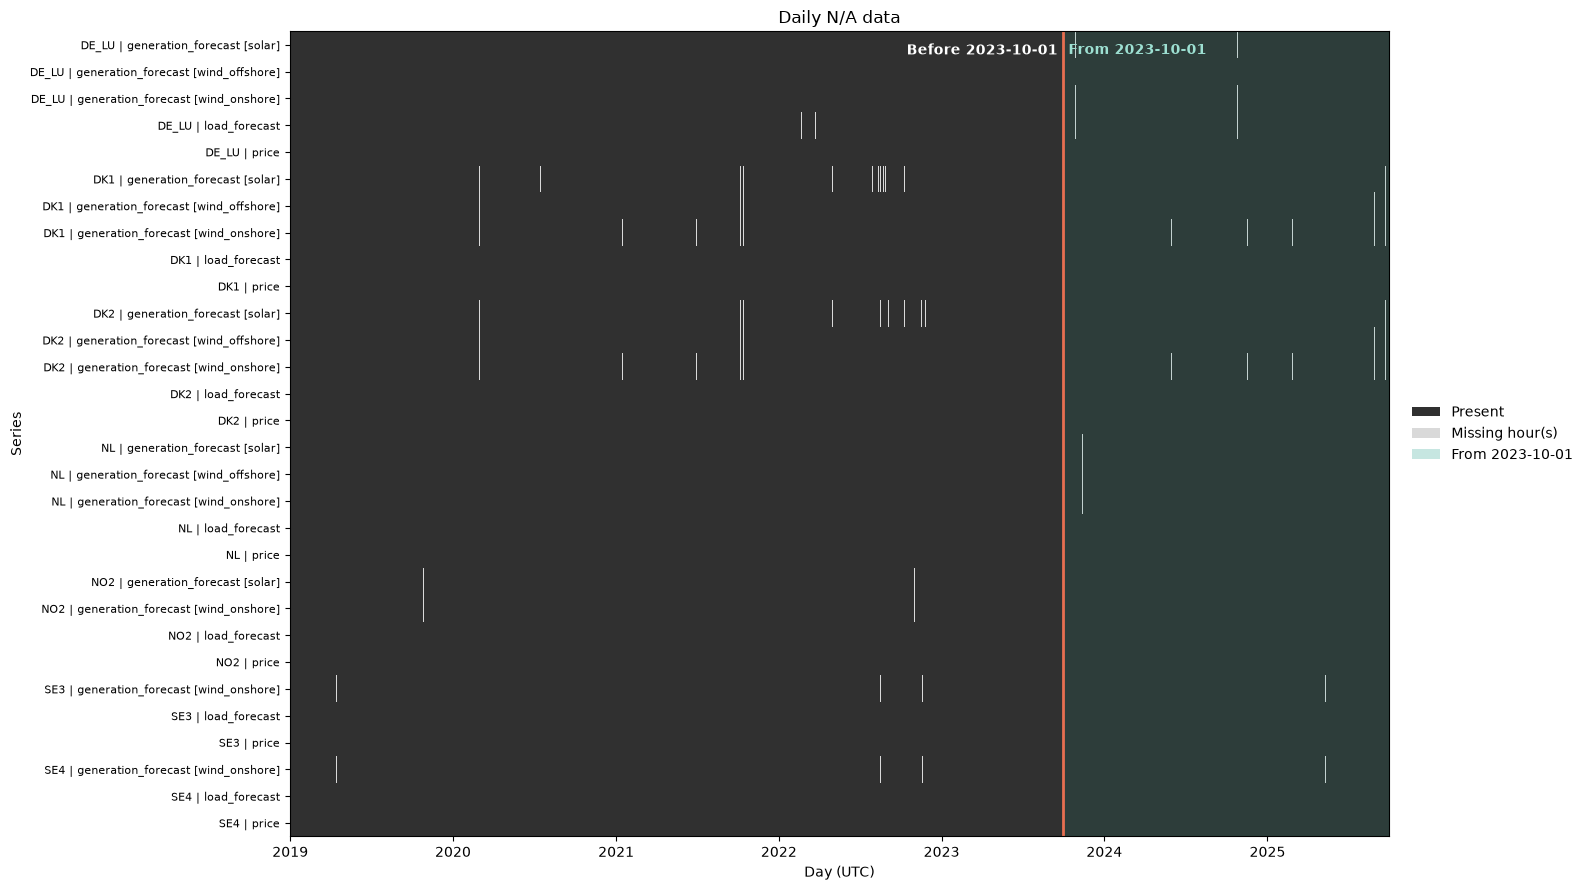

In [59]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch


def plot_missing_values(data, cutoff="2023-10-01"):
    """Plot whether each series contains every expected UTC hour per day."""
    series_order = sorted(data.series.unique())
    hour_grid = pd.date_range(
        data.timestamp_utc.min(), data.timestamp_utc.max(), freq="h"
    )
    day_grid = pd.date_range(
        hour_grid.min().floor("D"), hour_grid.max().floor("D"), freq="D"
    )
    expected = pd.Series(hour_grid.floor("D")).value_counts().reindex(day_grid)
    observed = (
        data.assign(day_utc=data.timestamp_utc.dt.floor("D"))
            .groupby(["series", "day_utc"], observed=True)
            .size()
            .unstack(fill_value=0)
            .reindex(index=series_order, columns=day_grid, fill_value=0)
    )
    daily_presence = observed.eq(expected, axis="columns")

    year_start = pd.Timestamp(year=day_grid.min().year, month=1, day=1, tz="UTC")
    year_starts = pd.date_range(year_start, day_grid.max(), freq="YS")
    year_starts = year_starts[year_starts >= day_grid.min()]
    year_positions = day_grid.searchsorted(year_starts)

    fig, ax = plt.subplots(figsize=(16, 9))
    ax.imshow(daily_presence.to_numpy(), aspect="auto", interpolation="nearest",
              cmap=ListedColormap(["#d9d9d9", "#303030"]), vmin=0, vmax=1)

    legend = [Patch(facecolor="#303030", label="Present"),
              Patch(facecolor="#d9d9d9", label="Missing hour(s)")]
    if cutoff is not None:
        cutoff = pd.Timestamp(cutoff, tz="UTC")
        cutoff_position = day_grid.searchsorted(cutoff) - 0.5
        if -0.5 < cutoff_position < len(day_grid) - 0.5:
            ax.axvspan(cutoff_position, len(day_grid) - 0.5,
                       color="#1f9e89", alpha=0.12)
            ax.axvline(cutoff_position, color="#e76f51", linewidth=2)
            ax.text(cutoff_position - 12, 0.985, f"Before {cutoff.date()}",
                    ha="right", va="top", transform=ax.get_xaxis_transform(),
                    color="white", fontweight="bold")
            ax.text(cutoff_position + 12, 0.985, f"From {cutoff.date()}",
                    ha="left", va="top", transform=ax.get_xaxis_transform(),
                    color="#9de0d2", fontweight="bold")
            legend.append(Patch(facecolor="#1f9e89", alpha=0.25,
                                label=f"From {cutoff.date()}"))

    ax.set_yticks(np.arange(len(series_order)), labels=series_order, fontsize=8)
    ax.set_xticks(year_positions, labels=year_starts.year)
    ax.set_xlabel("Day (UTC)")
    ax.set_ylabel("Series")
    ax.set_title("Daily N/A data")
    ax.legend(handles=legend, loc="center left", bbox_to_anchor=(1.01, 0.5),
              frameon=False)
    fig.tight_layout()
    plt.show()
    return fig, ax, daily_presence


fig, ax, daily_presence = plot_missing_values(panel)

Solar and load gaps are filled from the same hour one week earlier. Wind gaps are filled by cross-zonal OLS using available zones with the same wind type. Each wind model is fitted once at the start of a gap using only complete observations strictly before that gap; contemporaneous neighbour-zone forecasts supply the predictors for the missing hours. Predictions are clipped at zero.

In [60]:
WEEK = pd.Timedelta(days=7)
MIN_REGRESSION_HOURS = 24 * 28


def missing_hours(group):
    stamps = pd.DatetimeIndex(group.timestamp_utc.unique()).sort_values()
    return pd.date_range(stamps.min(), stamps.max(), freq="h").difference(stamps)


def gap_groups(stamps):
    values = pd.Series(stamps, index=stamps)
    breaks = (values.diff() != pd.Timedelta(hours=1)).cumsum()
    return [pd.DatetimeIndex(run.index) for _, run in values.groupby(breaks)]


def row_for_fill(group, timestamp):
    source = timestamp - WEEK
    prior_week = group[group.timestamp_utc == source]
    if len(prior_week):
        row = prior_week.iloc[0].copy()
    else:
        history = group[group.timestamp_utc < timestamp]
        if history.empty:
            raise KeyError(f"no earlier metadata row for {group.name!r} at {timestamp}")
        row = history.iloc[-1].copy()
    row["timestamp_utc"] = timestamp
    return row


def weekly_lag_fill(group, stamps):
    by_timestamp = group.set_index("timestamp_utc").to_dict("index")
    rows = []
    for timestamp in stamps:
        source = timestamp - WEEK
        if source not in by_timestamp:
            raise KeyError(
                f"{group.name!r} has no value at {source} to fill {timestamp} from"
            )
        row = dict(by_timestamp[source], timestamp_utc=timestamp,
                   imputation_method="same_hour_previous_week",
                   imputation_predictors="")
        rows.append(row)
        by_timestamp[timestamp] = row
    return rows


def wind_regression_fill(data, group, stamps):
    psr_type = group.psr_type.iloc[0]
    target_zone = str(group.zone.iloc[0])
    wind = data[
        (data.variable == "generation_forecast")
        & (data.psr_type == psr_type)
    ].pivot(index="timestamp_utc", columns="zone", values="value")
    wind.columns = wind.columns.astype(str)

    rows = []
    for run in gap_groups(stamps):
        predictors = [
            zone for zone in wind.columns
            if zone != target_zone
            and wind.loc[run, zone].notna().all()
        ]
        if not predictors:
            raise ValueError(f"no complete neighbour zone for {group.name!r} at {run[0]}")

        train = wind.loc[wind.index < run[0], [target_zone, *predictors]].dropna()
        if len(train) < MIN_REGRESSION_HOURS:
            raise ValueError(
                f"only {len(train)} past training hours for {group.name!r} at {run[0]}"
            )
        assert train.index.max() < run[0], "wind regression training leaked future data"

        x_train = train[predictors].to_numpy(dtype=float)
        y_train = train[target_zone].to_numpy(dtype=float)
        center = x_train.mean(axis=0)
        scale = x_train.std(axis=0)
        scale[scale == 0] = 1
        design = np.column_stack([np.ones(len(train)), (x_train - center) / scale])
        coefficients = np.linalg.lstsq(design, y_train, rcond=None)[0]

        x_gap = wind.loc[run, predictors].to_numpy(dtype=float)
        gap_design = np.column_stack([np.ones(len(run)), (x_gap - center) / scale])
        predictions = np.maximum(gap_design @ coefficients, 0)
        predictor_label = ",".join(predictors)

        for timestamp, prediction in zip(run, predictions):
            row = row_for_fill(group, timestamp)
            row["value"] = prediction
            row["imputation_method"] = "causal_cross_zone_ols"
            row["imputation_predictors"] = predictor_label
            rows.append(row.to_dict())
    return rows


def fill_exogenous_gaps(data):
    rows = []
    for series, group in data.groupby("series", observed=True):
        stamps = missing_hours(group)
        if not len(stamps):
            continue
        group = group.copy()
        group.name = series
        variable = group.variable.iloc[0]
        psr_type = group.psr_type.iloc[0]
        if variable == "load_forecast" or psr_type == "solar":
            rows.extend(weekly_lag_fill(group, stamps))
        elif psr_type in {"wind_onshore", "wind_offshore"}:
            rows.extend(wind_regression_fill(data, group, stamps))
        else:
            raise ValueError(f"no gap-filling rule for {series!r}")
    return pd.DataFrame(rows)


filled = fill_exogenous_gaps(panel)
filled["imputed"] = True

n = len(panel)
panel = pd.concat([
    panel.assign(imputed=False, imputation_method="observed",
                 imputation_predictors=""),
    filled,
], ignore_index=True).sort_values(["series", "timestamp_utc"], ignore_index=True)

assert not panel.duplicated(["series", "timestamp_utc"]).any(), \
    "filling created a duplicate series-hour"
assert gap_runs(panel).empty, "an hourly gap remains after filling"

print(f"fill exogenous gaps: {n:,} -> {len(panel):,}  (+{len(filled):,})")
display(filled.groupby(["imputation_method", "series"], observed=True)
              .size().rename("hours_filled").to_frame())

fill exogenous gaps: 1,772,580 -> 1,774,770  (+2,190)


hours_filled
imputation_method       series                                                  
causal_cross_zone_ols   DE_LU | generation_forecast [wind_onshore]             2
                        DK1 | generation_forecast [wind_offshore]            216
                        DK1 | generation_forecast [wind_onshore]             306
                        DK2 | generation_forecast [wind_offshore]            216
                        DK2 | generation_forecast [wind_onshore]             312
                        NL | generation_forecast [wind_offshore]              24
                        NL | generation_forecast [wind_onshore]               24
                        NO2 | generation_forecast [wind_onshore]              50
                        SE3 | generation_forecast [wind_onshore]              96
                        SE4 | generation_forecast [wind_onshore]              96
same_hour_previous_week DE_LU | generation_forecast [solar]                    2
                        DE_LU | load_forecast                                 50
                        DK1 | generation_forecast [solar]                    384
                        DK2 | generation_forecast [solar]                    338
                        NL | generation_forecast [solar]                      24
                        NO2 | generation_forecast [solar]                     50

In [61]:
variance_summary = (
    panel.groupby("series", observed=True)["value"]
         .agg(observations="size", mean="mean", mean_abs=lambda s: s.abs().mean(),
              variance="var", std_dev="std", minimum="min", maximum="max",
              unique_values="nunique")
)
variance_summary["range"] = variance_summary.maximum - variance_summary.minimum
variance_summary["relative_std_pct"] = (
    100 * variance_summary.std_dev
    / variance_summary.mean_abs.replace(0, np.nan)
)
variance_summary["exactly_constant"] = variance_summary.unique_values <= 1
variance_summary["practically_zero_variance"] = (
    variance_summary.exactly_constant
    | (variance_summary.std_dev <= 0.001 * variance_summary.mean_abs)
)
variance_summary = variance_summary.sort_values(
    ["practically_zero_variance", "relative_std_pct"],
    ascending=[False, True],
)

print(f"{int(variance_summary.exactly_constant.sum())} exactly constant series")
print(f"{int(variance_summary.practically_zero_variance.sum())} series with "
      f"std. dev. <= 0.1% of their mean absolute level")
display(variance_summary.round({
    "mean": 4, "mean_abs": 4, "variance": 4, "std_dev": 4,
    "minimum": 4, "maximum": 4, "range": 4, "relative_std_pct": 6,
}))

1 exactly constant series
1 series with std. dev. <= 0.1% of their mean absolute level


,observations,mean,mean_abs,variance,std_dev,minimum,maximum,unique_values,range,relative_std_pct,exactly_constant,practically_zero_variance
series,,,,,,,,,,,,
NO2 | generation_forecast [solar],59159,0.0000,0.0000,0.000000e+00,0.0000,0.0000,0.0000,1,0.0000,NaN,True,True
DE_LU | load_forecast,59159,54612.6254,54612.6254,8.545000e+07,9243.9170,30893.0550,78154.3700,58999,47261.3150,16.926337,False,False
DK1 | load_forecast,59159,2475.6159,2475.6159,2.007186e+05,448.0163,1171.0000,3943.0000,7737,2772.0000,18.097165,False,False
DK2 | load_forecast,59159,1540.9378,1540.9378,8.798397e+04,296.6209,819.0000,2559.0000,6494,1740.0000,19.249377,False,False
NL | load_forecast,59159,11398.5935,11398.5935,5.051330e+06,2247.5164,478.7700,21256.9225,58606,20778.1525,19.717489,False,False
NO2 | load_forecast,59159,3936.0285,3936.0285,6.799582e+05,824.5958,1951.9700,6759.7400,54323,4807.7700,20.949944,False,False
SE3 | load_forecast,59159,9645.7850,9645.7850,4.482597e+06,2117.2145,5130.0000,16856.0000,9210,11726.0000,21.949634,False,False
SE4 | load_forecast,59159,2600.2116,2600.2116,3.798451e+05,616.3158,1301.0000,4921.0000,2997,3620.0000,23.702524,False,False
DK1 | generation_forecast [wind_offshore],59159,543.3397,543.3397,1.052191e+05,324.3750,0.0000,1157.9200,29071,1157.9200,59.700221,False,False


In [62]:
NO2_SOLAR = "NO2 | generation_forecast [solar]"

n_rows = len(panel)
n_series = panel.series.nunique()
panel = panel[panel.series != NO2_SOLAR].copy()

assert NO2_SOLAR not in set(panel.series), "NO2 solar forecast survived"
print(f"drop series {NO2_SOLAR!r}: "
      f"{n_series} -> {panel.series.nunique()} series, "
      f"{n_rows:,} -> {len(panel):,} rows  (-{n_rows - len(panel):,})")

drop series 'NO2 | generation_forecast [solar]': 30 -> 29 series, 1,774,770 -> 1,715,611 rows  (-59,159)


In [63]:
from local_day_panel import normalize_local_hourly_panel

OUT = RAW.parent / "nordic_baltic_clean_hourly_local.parquet"

assert not panel.duplicated(["series", "timestamp_utc"]).any(), \
    "duplicate UTC series-hour before local-time normalization"
assert not panel.value.isna().any(), "missing values before local-time normalization"
assert gap_runs(panel).empty, "an hourly UTC gap remains before local-time normalization"

local_panel, dst_report = normalize_local_hourly_panel(panel, MARKET_TIMEZONE)
per_day = local_panel.groupby(
    ["series", local_panel["timestamp_local"].dt.normalize()], observed=True
).size()

assert "timestamp_utc" not in local_panel, "UTC timestamp survived the local output conversion"
assert local_panel["timestamp_local"].dt.tz is None, "local output timestamps are timezone-aware"
assert not local_panel.duplicated(["series", "timestamp_local"]).any(), \
    "duplicate local series-hour before export"
assert not local_panel.value.isna().any(), "missing values before export"
assert per_day.eq(24).all(), "a local delivery day does not contain exactly 24 hours"

local_panel.to_parquet(OUT, index=False)

print(f"written: {OUT.resolve()}")
print(f"{len(local_panel):,} rows x {local_panel.shape[1]} columns | "
      f"{local_panel.series.nunique()} series | {OUT.stat().st_size / 1e6:.1f} MB")
print(f"local span: {local_panel.timestamp_local.min()} -> "
      f"{local_panel.timestamp_local.max()} ({MARKET_TIMEZONE}, naive)")
print(f"DST normalized during cleaning: {len(dst_report.spring_days)} spring and "
      f"{len(dst_report.autumn_days)} autumn transition days")

written: C:\Users\Frede\OneDrive\Skrivebord\Masters Thesis v2\Code\EPF_Masters\datasets\nordic_baltic_clean_hourly_local.parquet
1,715,640 rows x 21 columns | 29 series | 12.1 MB
local span: 2019-01-01 00:00:00 -> 2025-09-30 23:00:00 (Europe/Copenhagen, naive)
DST normalized during cleaning: 7 spring and 6 autumn transition days
